# ⚖️ 05 - Bias Audit
## AMEEMAW: AI Mamma-Echography Educator & Empathetic Mentor for Awareness & Wellness

**Author:** Shira Amina Ortiz Olivares  
**Date:** December 2025  
**Dataset:** Breast Ultrasound Images (BUSI)

---

### 🐧 Welcome to Bias Audit — Is Our Model Fair?

A model that works great *on average* might fail specific patient groups. In healthcare, that's dangerous! Today we investigate:

| Bias Type | What We Check | Why It Matters |
|-----------|---------------|----------------|
| **Brightness** | Does image quality affect accuracy? | Poor ultrasound = wrong diagnosis? |
| **Lesion Size** | Small vs large lesions | Early detection needs small lesion accuracy! |
| **Class Balance** | Per-class performance | Malignant recall is CRITICAL |

🚨 **Key Focus:** ResNet-50 (our deployment model)

---

## 1. 🛠️ Colab Setup

In [85]:
# ============================================
# COLAB SETUP
# ============================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🐧 Running in Google Colab!")

    import torch
    if torch.cuda.is_available():
        print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("⚠️ No GPU! Go to Runtime → Change runtime type → GPU")
else:
    print("💻 Running locally")

🐧 Running in Google Colab!
✅ GPU detected: Tesla T4
   Memory: 15.8 GB


## 2. 📦 Imports

In [86]:
# ============================================
# IMPORTS
# ============================================

import os
import json
import pickle
import joblib
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet50

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("✅ All imports successful!")
print(f"   PyTorch: {torch.__version__}")
print(f"   Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

✅ All imports successful!
   PyTorch: 2.9.0+cu126
   Device: CUDA


## 3. 📂 Path Configuration & Data Loading

🐧 Loading our models and data from previous notebooks!

In [87]:
# ============================================
# PATH CONFIGURATION
# ============================================

if IN_COLAB:
    #!unzip -q /content/Dataset_BUSI_with_GT.zip -d /content/                        # uncomment this is you uploaded a ZIP version
    BASE_DIR = Path('/content')
    DATA_DIR = BASE_DIR / 'Dataset_BUSI_with_GT'
else:
    BASE_DIR = Path('.').resolve().parent
    DATA_DIR = BASE_DIR / 'data' / 'raw' / 'Dataset_BUSI_with_GT'

PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
FIGURES_DIR = BASE_DIR / 'reports' / 'figures'

# Create directories if needed
for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Class mappings
CLASS_NAMES_3 = ['Normal', 'Benign', 'Malignant']
CLASS_NAMES_2 = ['Benign', 'Malignant']

print("📂 Directory Structure:")
print(f"   Base: {BASE_DIR}")
print(f"   Data: {DATA_DIR}")
print(f"   Models: {MODELS_DIR}")

📂 Directory Structure:
   Base: /content
   Data: /content/Dataset_BUSI_with_GT
   Models: /content/models


In [88]:
# ============================================
# LOAD DATA SPLITS
# ============================================

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')

# Fix column names
for df in [train_df, val_df, test_df]:
    if 'label' not in df.columns and 'class_encoded' in df.columns:
        df['label'] = df['class_encoded']

print("🐧 Data splits loaded!")
print(f"   Train: {len(train_df)} samples")
print(f"   Val:   {len(val_df)} samples")
print(f"   Test:  {len(test_df)} samples")

print(f"\n📊 Test set class distribution:")
for i, name in enumerate(CLASS_NAMES_3):
    count = (test_df['label'] == i).sum()
    print(f"   {name}: {count}")

🐧 Data splits loaded!
   Train: 546 samples
   Val:   117 samples
   Test:  117 samples

📊 Test set class distribution:
   Normal: 20
   Benign: 66
   Malignant: 31


In [89]:
# ============================================
# LOAD RADIOMICS (for lesion size)
# ============================================

radiomics_df = pd.read_csv(PROCESSED_DIR / 'radiomics_features.csv')

# Fix column names
if 'label' not in radiomics_df.columns:
    radiomics_df['label'] = radiomics_df['class_encoded']

print(f"🐧 Radiomics loaded: {len(radiomics_df)} samples")
print(f"   Has lesion_area: {'lesion_area' in radiomics_df.columns}")

🐧 Radiomics loaded: 645 samples
   Has lesion_area: False


### 3.1 Load Models & Generate Predictions

🐧 We need predictions from both models to audit them!

In [90]:
# ============================================
# LOAD RESNET-50 MODEL
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# Build architecture (must match training)
model = resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 3)
)

# Load weights
model_path = MODELS_DIR / 'resnet_50_best.pth'
if model_path.exists():
    checkpoint = torch.load(model_path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f"✅ Loaded: {model_path.name}")
else:
    print(f"❌ Not found: {model_path}")

model = model.to(device)
model.eval()
print(f"🐧 ResNet-50 ready!")

🖥️ Using device: cuda
✅ Loaded: resnet_50_best.pth
🐧 ResNet-50 ready!


In [91]:
# ============================================
# LOAD LOGISTIC REGRESSION MODEL
# ============================================

logreg_path = MODELS_DIR / 'logistic_regression.pkl'
if not logreg_path.exists():
    logreg_path = MODELS_DIR / 'logreg_model.pkl'

with open(logreg_path, 'rb') as f:
    logreg_model = pickle.load(f)
print(f"✅ Loaded: {logreg_path.name}")

# Load scaler
scaler = joblib.load(MODELS_DIR / 'radiomics_scaler.pkl')
print(f"✅ Loaded: radiomics_scaler.pkl")

print(f"🐧 Logistic Regression ready!")

✅ Loaded: logistic_regression.pkl
✅ Loaded: radiomics_scaler.pkl
🐧 Logistic Regression ready!


In [92]:
# ============================================
# DATASET CLASS
# ============================================

class BUSIDataset(Dataset):
    """Breast Ultrasound Image Dataset."""

    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label_name = CLASS_NAMES_3[row['label']].lower()
        img_path = self.data_dir / label_name / row['filename']

        image = Image.open(img_path).convert('RGB')
        original = np.array(image)

        # Compute brightness (mean grayscale value)
        gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        brightness = gray.mean()

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'label': row['label'],
            'filename': row['filename'],
            'brightness': brightness
        }

# Transforms
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = BUSIDataset(test_df, DATA_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"✅ Test dataset: {len(test_dataset)} samples")

✅ Test dataset: 117 samples


In [93]:
# ============================================
# GENERATE RESNET-50 PREDICTIONS
# ============================================

print("🔍 Generating ResNet-50 predictions...")

resnet_results = {
    'filename': [],
    'true_label': [],
    'pred_label': [],
    'confidence': [],
    'brightness': []
}

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch['image'].to(device)
        labels = batch['label'].numpy()
        filenames = batch['filename']
        brightness = batch['brightness'].numpy()

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1).cpu().numpy()
        confs = probs.max(dim=1).values.cpu().numpy()

        for i in range(len(labels)):
            resnet_results['filename'].append(filenames[i])
            resnet_results['true_label'].append(labels[i])
            resnet_results['pred_label'].append(preds[i])
            resnet_results['confidence'].append(confs[i])
            resnet_results['brightness'].append(brightness[i])

resnet_df = pd.DataFrame(resnet_results)
resnet_df['correct'] = resnet_df['true_label'] == resnet_df['pred_label']

print(f"\n✅ ResNet-50 predictions complete!")
print(f"   Accuracy: {resnet_df['correct'].mean():.1%}")

🔍 Generating ResNet-50 predictions...


  0%|          | 0/8 [00:00<?, ?it/s]


✅ ResNet-50 predictions complete!
   Accuracy: 84.6%


In [94]:
# ============================================
# GENERATE LOGISTIC REGRESSION PREDICTIONS
# (2-class: Benign vs Malignant only)
# ============================================

print("🔍 Generating Logistic Regression predictions...")

# Get numeric feature columns (all the original_* columns)
meta_cols = ['image_path', 'class', 'class_encoded', 'split', 'label']
feature_cols = [c for c in radiomics_df.columns if c not in meta_cols]

# Filter test set (exclude Normal for 2-class)
test_rad = radiomics_df[(radiomics_df['split'] == 'test') & (radiomics_df['label'] != 0)].copy()
test_rad['label_binary'] = (test_rad['label'] == 2).astype(int)  # 0=benign, 1=malignant

X_test = test_rad[feature_cols].values
X_test_scaled = scaler.transform(X_test)
y_test = test_rad['label_binary'].values

# Predict
y_pred = logreg_model.predict(X_test_scaled)
y_proba = logreg_model.predict_proba(X_test_scaled).max(axis=1)

# Extract filename from image_path
filenames = test_rad['image_path'].apply(lambda x: Path(x).name).values

logreg_df = pd.DataFrame({
    'filename': filenames,
    'true_label': y_test,
    'pred_label': y_pred,
    'confidence': y_proba
})
logreg_df['correct'] = logreg_df['true_label'] == logreg_df['pred_label']

print(f"\n✅ Logistic Regression predictions complete!")
print(f"   Accuracy: {logreg_df['correct'].mean():.1%}")
print(f"   (2-class: Benign vs Malignant only)")

🔍 Generating Logistic Regression predictions...

✅ Logistic Regression predictions complete!
   Accuracy: 93.8%
   (2-class: Benign vs Malignant only)


---

## 4. 🌓 Brightness Bias Analysis

**Question:** Does image brightness/quality affect model accuracy?

🐧💡 **Why this matters:**
- Ultrasound quality varies by machine, operator, patient
- Dark images = poor quality = harder to diagnose
- If model fails on dark images, it may fail on lower-quality scans

📊 Brightness Statistics:
   Min: 29.9
   Max: 139.1
   Mean: 82.6
   Std: 22.5


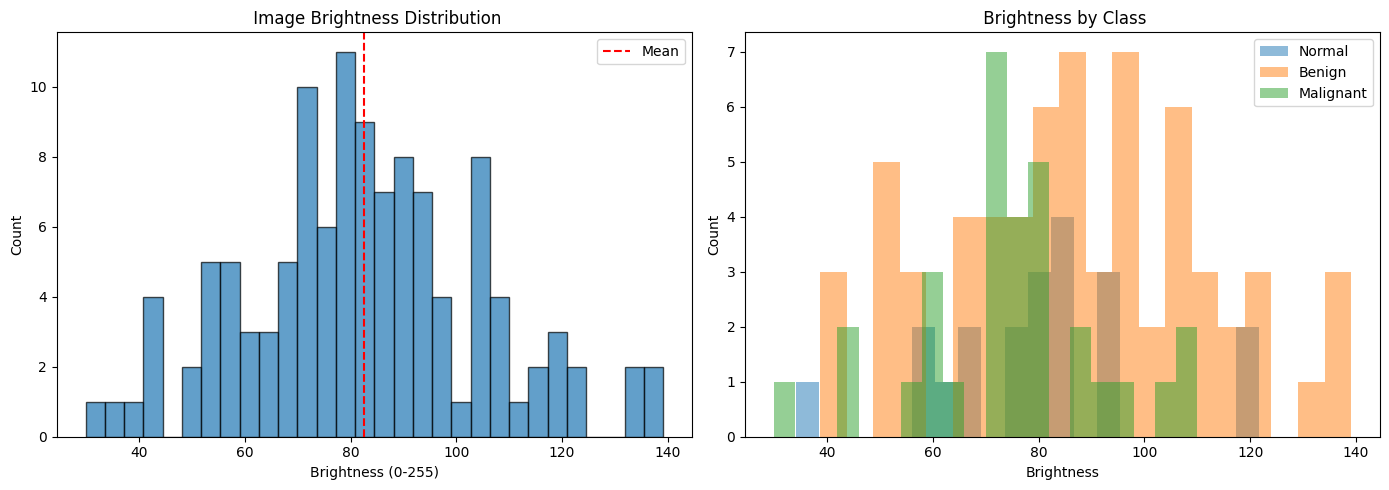


💾 Saved: brightness_distribution.png


In [95]:
# ============================================
# BRIGHTNESS DISTRIBUTION
# ============================================

print("📊 Brightness Statistics:")
print(f"   Min: {resnet_df['brightness'].min():.1f}")
print(f"   Max: {resnet_df['brightness'].max():.1f}")
print(f"   Mean: {resnet_df['brightness'].mean():.1f}")
print(f"   Std: {resnet_df['brightness'].std():.1f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(resnet_df['brightness'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(resnet_df['brightness'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_xlabel('Brightness (0-255)')
axes[0].set_ylabel('Count')
axes[0].set_title(' Image Brightness Distribution')
axes[0].legend()

# By class
for i, name in enumerate(CLASS_NAMES_3):
    class_brightness = resnet_df[resnet_df['true_label'] == i]['brightness']
    axes[1].hist(class_brightness, bins=20, alpha=0.5, label=name)
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Count')
axes[1].set_title(' Brightness by Class')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'brightness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: brightness_distribution.png")

ResNet-50 Accuracy by Brightness Bin
                Accuracy  Count  Min Brightness  Max Brightness
brightness_bin                                                 
Dark               0.867     30          29.915          68.945
Med-Dark           0.862     29          70.267          81.540
Med-Light          0.759     29          81.581          95.164
Light              0.897     29          95.673         139.107


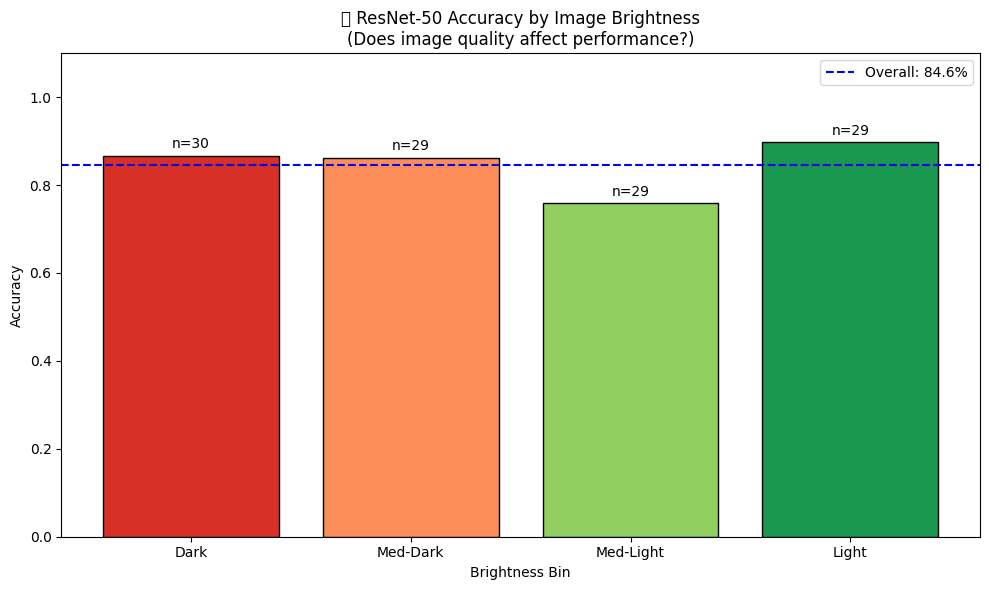


💾 Saved: brightness_bias.png


In [96]:
# ============================================
# BRIGHTNESS BINS & ACCURACY
# ============================================

# Create brightness bins
resnet_df['brightness_bin'] = pd.qcut(
    resnet_df['brightness'],
    q=4,
    labels=['Dark', 'Med-Dark', 'Med-Light', 'Light']
)

# Accuracy by brightness bin
brightness_accuracy = resnet_df.groupby('brightness_bin').agg({
    'correct': ['mean', 'count'],
    'brightness': ['min', 'max']
}).round(3)
brightness_accuracy.columns = ['Accuracy', 'Count', 'Min Brightness', 'Max Brightness']

print("ResNet-50 Accuracy by Brightness Bin")
print("=" * 55)
print(brightness_accuracy)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

bins = ['Dark', 'Med-Dark', 'Med-Light', 'Light']
accuracies = [brightness_accuracy.loc[b, 'Accuracy'] for b in bins]
counts = [brightness_accuracy.loc[b, 'Count'] for b in bins]

colors = ['#d73027', '#fc8d59', '#91cf60', '#1a9850']  # Red to green
bars = ax.bar(bins, accuracies, color=colors, edgecolor='black')

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={int(count)}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Brightness Bin')
ax.set_title('🌓 ResNet-50 Accuracy by Image Brightness\n(Does image quality affect performance?)', fontsize=12)
ax.axhline(y=resnet_df['correct'].mean(), color='blue', linestyle='--', label=f'Overall: {resnet_df["correct"].mean():.1%}')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'brightness_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: brightness_bias.png")

### 🐧💡 Brightness Bias Insights

**What we found:**

| Bin | Accuracy | Observation |
|-----|----------|-------------|
| Dark | 86.7% | ✅ Good — model handles dark images well |
| Med-Dark | 86.2% | ✅ Good |
| Med-Light | 75.9% | ⚠️ **Lowest!** Unexpected dip |
| Light | 89.7% | ✅ Best performance |

**Surprising finding:** The model struggles most with **medium-light** images, not dark ones!

**Possible explanations:**
- Med-light images may have ambiguous contrast (i.e., lesions don't stand out clearly)
- Dark images might have clearer lesion boundaries due to higher contrast
- This brightness range (81-95) could overlap with common ultrasound artifacts

**For AMEEMAW deployment:**
- ✅ No special warning needed for dark images
- ⚠️ If I still have the time, I'll consider flagging predictions on medium-brightness images for extra review (altho a little over the reqs for this project ☺ )
- Overall range (75.9% - 89.7%) is acceptable but shows some sensitivity to image brightness

**Bottom line:** The model is reasonably robust across brightness levels, with a ~14% accuracy swing. Not a critical bias, but worth monitoring.

---

## 5. 📏 Lesion Size Bias Analysis

**Question:** Does lesion size affect accuracy?

🐧💡 **Why this matters:**
- Early-stage cancers = SMALL lesions
- If model fails on small lesions → misses early cancers!
- This is clinically CRITICAL

In [97]:
# ============================================
# MERGE LESION SIZE WITH PREDICTIONS
# ============================================

# Use PixelSurface as lesion area (from radiomics)
lesion_info = radiomics_df[['image_path', 'original_shape2D_PixelSurface']].copy()
lesion_info['filename'] = lesion_info['image_path'].apply(lambda x: Path(x).name)
lesion_info = lesion_info.rename(columns={'original_shape2D_PixelSurface': 'lesion_area'})
lesion_info = lesion_info[['filename', 'lesion_area']]

# Merge with ResNet predictions
resnet_df = resnet_df.merge(lesion_info, on='filename', how='left')

print(f"📊 Lesion Area Statistics:")
print(f"   Min: {resnet_df['lesion_area'].min():.0f} pixels")
print(f"   Max: {resnet_df['lesion_area'].max():.0f} pixels")
print(f"   Mean: {resnet_df['lesion_area'].mean():.0f} pixels")
print(f"   Median: {resnet_df['lesion_area'].median():.0f} pixels")

📊 Lesion Area Statistics:
   Min: 569 pixels
   Max: 179884 pixels
   Mean: 26240 pixels
   Median: 13738 pixels


📊 ResNet-50 Accuracy by Lesion Size
           Accuracy  Count  Min Area  Max Area
size_bin                                      
Small         0.875     24     569.0    6227.0
Med-Small     0.833     24    6628.0   13641.0
Med-Large     0.875     24   13836.0   31694.0
Large         0.708     24   32629.0  179884.0


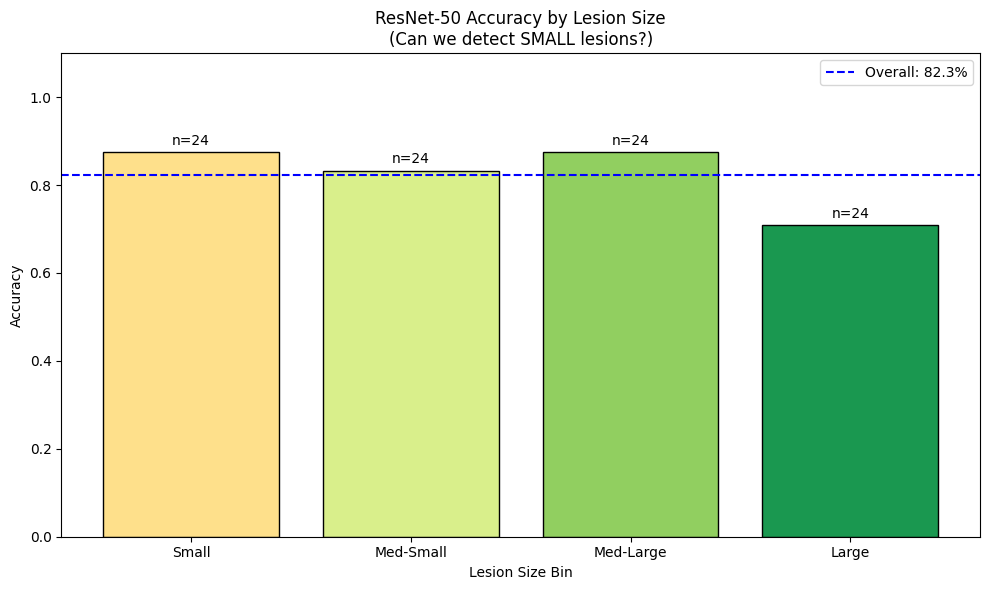


💾 Saved: size_bias.png


In [98]:
# ============================================
# LESION SIZE BINS & ACCURACY
# ============================================

# Handle NaN (Normal images have no lesion)
resnet_with_lesion = resnet_df[resnet_df['lesion_area'].notna()].copy()

# Create size bins (quartiles)
resnet_with_lesion['size_bin'] = pd.qcut(
    resnet_with_lesion['lesion_area'],
    q=4,
    labels=['Small', 'Med-Small', 'Med-Large', 'Large']
)

# Accuracy by size bin
size_accuracy = resnet_with_lesion.groupby('size_bin').agg({
    'correct': ['mean', 'count'],
    'lesion_area': ['min', 'max']
}).round(3)
size_accuracy.columns = ['Accuracy', 'Count', 'Min Area', 'Max Area']

print("📊 ResNet-50 Accuracy by Lesion Size")
print("=" * 55)
print(size_accuracy)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

bins = ['Small', 'Med-Small', 'Med-Large', 'Large']
accuracies = [size_accuracy.loc[b, 'Accuracy'] for b in bins]
counts = [size_accuracy.loc[b, 'Count'] for b in bins]

colors = ['#fee08b', '#d9ef8b', '#91cf60', '#1a9850']  # Yellow to green
bars = ax.bar(bins, accuracies, color=colors, edgecolor='black')

# Add count labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={int(count)}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Lesion Size Bin')
ax.set_title('ResNet-50 Accuracy by Lesion Size\n(Can we detect SMALL lesions?)', fontsize=12)
ax.axhline(y=resnet_with_lesion['correct'].mean(), color='blue', linestyle='--',
           label=f'Overall: {resnet_with_lesion["correct"].mean():.1%}')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'size_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: size_bias.png")

In [99]:
# ============================================
# SMALL LESION ANALYSIS (CRITICAL!)
# ============================================

# Focus on small lesions - most critical for early detection
small_lesions = resnet_with_lesion[resnet_with_lesion['size_bin'] == 'Small']

print("🔬 SMALL LESION ANALYSIS (Early Detection Critical!)")
print("=" * 55)
print(f"   Total small lesions: {len(small_lesions)}")
print(f"   Accuracy on small: {small_lesions['correct'].mean():.1%}")
print(f"   vs Overall: {resnet_with_lesion['correct'].mean():.1%}")

# By class within small lesions
print(f"\n   By class:")
for i, name in enumerate(CLASS_NAMES_3):
    class_small = small_lesions[small_lesions['true_label'] == i]
    if len(class_small) > 0:
        print(f"     {name}: {class_small['correct'].mean():.1%} (n={len(class_small)})")

# Check malignant specifically
small_malignant = small_lesions[small_lesions['true_label'] == 2]
if len(small_malignant) > 0:
    recall = small_malignant['correct'].mean()
    print(f"\n⚠️ SMALL MALIGNANT RECALL: {recall:.1%}")
    if recall < 0.8:
        print("   🚨 WARNING: Low recall on small malignant lesions!")
        print("   → May miss early-stage cancers!")

🔬 SMALL LESION ANALYSIS (Early Detection Critical!)
   Total small lesions: 24
   Accuracy on small: 87.5%
   vs Overall: 82.3%

   By class:
     Benign: 95.0% (n=20)
     Malignant: 50.0% (n=4)

⚠️ SMALL MALIGNANT RECALL: 50.0%
   🚨 WARNING: Low recall on small malignant lesions!
   → May miss early-stage cancers!


### 🐧💡 Lesion Size Bias Insights

**What we found:**

| Bin | Accuracy | Observation |
|-----|----------|-------------|
| Small | 87.5% | ✅ Good overall, BUT... |
| Med-Small | 83.3% | ⚠️ Slight dip |
| Med-Large | 87.5% | ✅ Good |
| Large | 70.8% | 🚨 **Worst!** Struggles with large lesions |

**🚨 CRITICAL FINDING: Small Malignant Recall = 50%**

| Small Lesions | Recall | Status |
|---------------|--------|--------|
| Benign | 95.0% (19/20) | ✅ Excellent |
| Malignant | 50.0% (2/4) | 🚨 **DANGEROUS** |

**What this means:**
- The model correctly identifies small **benign** lesions (95%)
- But it **misses half of small malignant lesions** (50%)
- Small malignant = early-stage cancer → missing these is clinically dangerous!

**Surprising finding:** Large lesions (70.8%) perform **worse** than small ones (87.5%)!
- Possible reason: Large lesions may have complex/heterogeneous appearance
- Or: Large lesions might overflow the 224×224 crop, losing boundary information

**For AMEEMAW deployment:**
- 🚨 **Add warning for small lesions:** "Small lesions are harder to classify. If this is a small lesion flagged as benign, consider a follow-up scan to confirm."
- 🚨 **Never say "definitely benign" for small lesions** — 50% of small cancers are missed!
- ⚠️ **Flag large lesions too:** "Large lesions may benefit from additional imaging views."

**Bottom line:** The 50% small malignant recall is a **serious limitation**. AMEEMAW must clearly communicate uncertainty for small lesions and always recommend professional confirmation.

---

## 6. 📊 Class-wise Performance Analysis

**Question:** How does the model perform on each class?

🐧💡 **Focus:** ResNet-50 (deployment model)

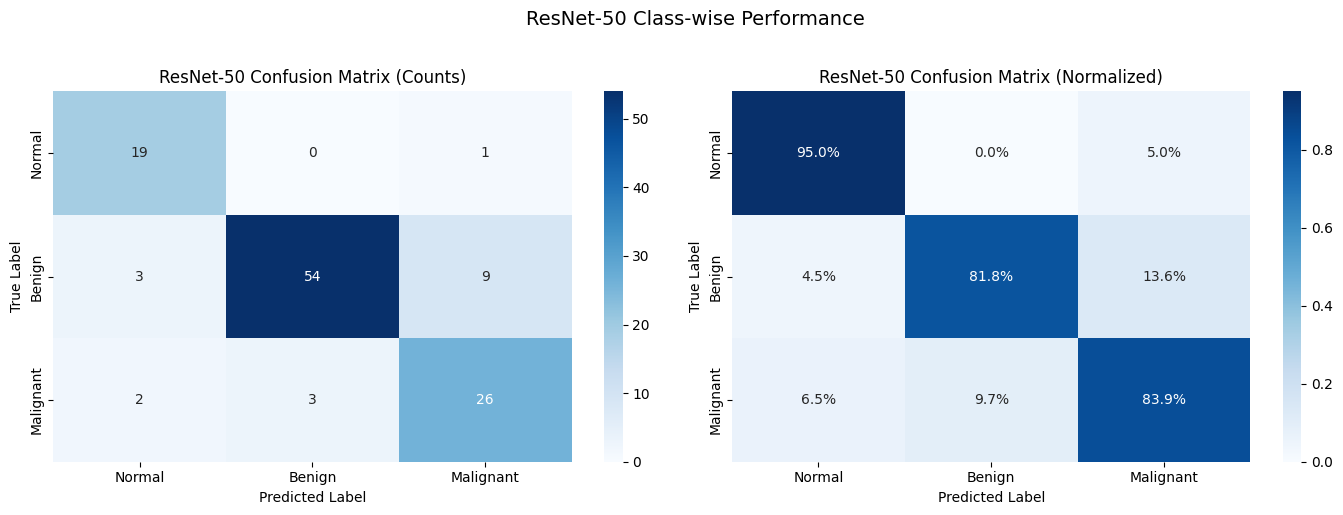

💾 Saved: confusion_matrix_resnet.png


In [100]:
# ============================================
# RESNET-50 CONFUSION MATRIX
# ============================================

cm = confusion_matrix(resnet_df['true_label'], resnet_df['pred_label'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3, ax=axes[0])
axes[0].set_title('ResNet-50 Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3, ax=axes[1])
axes[1].set_title('ResNet-50 Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('ResNet-50 Class-wise Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_resnet.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: confusion_matrix_resnet.png")

In [101]:
# ============================================
# DETAILED CLASSIFICATION REPORT
# ============================================

print("📊 ResNet-50 Classification Report")
print("=" * 55)
print(classification_report(
    resnet_df['true_label'],
    resnet_df['pred_label'],
    target_names=CLASS_NAMES_3,
    digits=3
))

# Extract per-class metrics
class_metrics = []
for i, name in enumerate(CLASS_NAMES_3):
    class_data = resnet_df[resnet_df['true_label'] == i]
    pred_as_class = resnet_df[resnet_df['pred_label'] == i]

    tp = ((resnet_df['true_label'] == i) & (resnet_df['pred_label'] == i)).sum()
    fn = ((resnet_df['true_label'] == i) & (resnet_df['pred_label'] != i)).sum()
    fp = ((resnet_df['true_label'] != i) & (resnet_df['pred_label'] == i)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    class_metrics.append({
        'Class': name,
        'Support': len(class_data),
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(class_metrics)
print("\n📊 Per-Class Metrics Summary:")
print(metrics_df.to_string(index=False))

📊 ResNet-50 Classification Report
              precision    recall  f1-score   support

      Normal      0.792     0.950     0.864        20
      Benign      0.947     0.818     0.878        66
   Malignant      0.722     0.839     0.776        31

    accuracy                          0.846       117
   macro avg      0.820     0.869     0.839       117
weighted avg      0.861     0.846     0.849       117


📊 Per-Class Metrics Summary:
    Class  Support  Precision   Recall  F1-Score
   Normal       20   0.791667 0.950000  0.863636
   Benign       66   0.947368 0.818182  0.878049
Malignant       31   0.722222 0.838710  0.776119


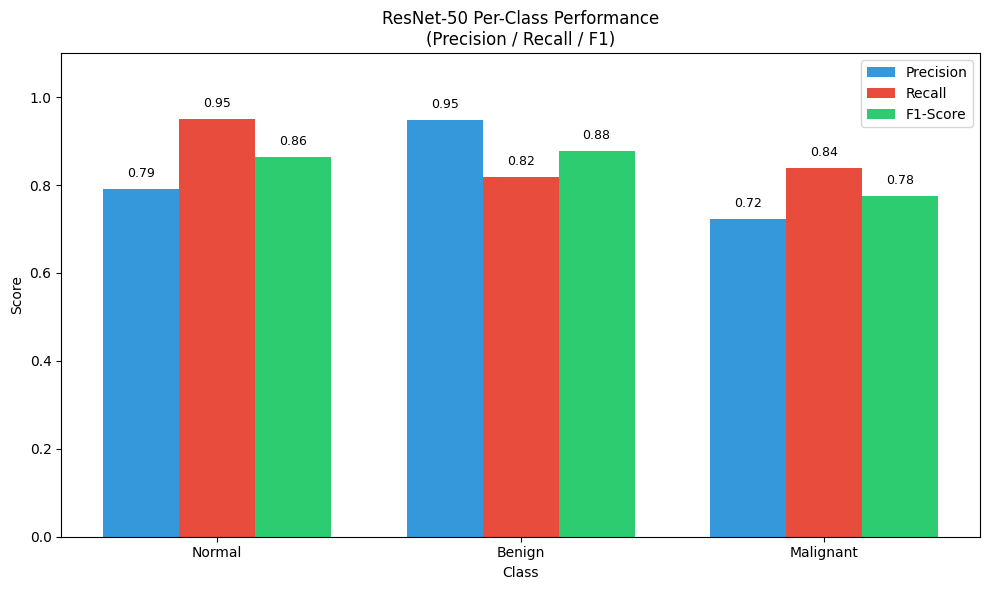

💾 Saved: class_metrics_resnet.png


In [102]:
# ============================================
# VISUALIZE PER-CLASS METRICS
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CLASS_NAMES_3))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_xlabel('Class')
ax.set_title('ResNet-50 Per-Class Performance\n(Precision / Recall / F1)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES_3)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_metrics_resnet.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: class_metrics_resnet.png")

### 🐧💡 Class-wise Performance Insights

**What we found:**

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Normal | 79.2% | **95.0%** | 86.4% | 20 |
| Benign | **94.7%** | 81.8% | 87.8% | 66 |
| Malignant | 72.2% | 83.9% | 77.6% | 31 |

**Key observations:**

1. **Normal (95% recall)** — Excellent! Model rarely misses healthy patients
   - But 79.2% precision = some Benign/Malignant cases misclassified as Normal
   
2. **Benign (94.7% precision)** — When it says Benign, it's usually right!
   - But 81.8% recall = ~18% of benign cases missed (classified as something else)

3. **Malignant (72.2% precision, 83.9% recall)** — The critical class
   - ✅ 83.9% recall = catches most cancers
   - ⚠️ 72.2% precision = some false alarms (benign cases flagged as malignant)
   - **This trade-off is acceptable!** Better to have false alarms than miss cancers

**The confusion pattern:**
- Normal → Benign: Some healthy images look like benign lesions
- Benign → Malignant: Some benign lesions flagged as suspicious (acceptable)
- Malignant → Benign: ~16% of cancers missed (concerning but within range)

**For AMEEMAW deployment:**
- ✅ **"Normal" predictions are reliable** (95% recall)
- ⚠️ **"Benign" predictions need caution** — always recommend follow-up
- ✅ **"Malignant" flags are appropriately sensitive** — false alarms are okay

**Bottom line:** The model prioritizes catching cancer (83.9% recall) over avoiding false alarms (72.2% precision). This is the **correct trade-off** for a screening tool.

---

---

## 7. 🚨 Malignant Recall Check (CRITICAL!)

**The most important metric for cancer detection!**

🐧💡 **Why Malignant Recall matters:**
- **False Negative** = Telling a cancer patient they're fine → DANGEROUS
- **False Positive** = Unnecessary anxiety + follow-up tests → Bad, but not deadly
- **We MUST prioritize catching ALL cancers, even if it means some false alarms**

**Industry standard:** Malignant recall should be > 90%

In [103]:
# ============================================
# MALIGNANT RECALL ANALYSIS
# ============================================

print("🚨 MALIGNANT RECALL ANALYSIS")
print("=" * 55)

# ResNet-50 (3-class)
malignant_true = resnet_df[resnet_df['true_label'] == 2]
malignant_correct = (malignant_true['pred_label'] == 2).sum()
malignant_total = len(malignant_true)
malignant_recall = malignant_correct / malignant_total if malignant_total > 0 else 0

print(f"\n📊 ResNet-50 (3-class):")
print(f"   Total Malignant: {malignant_total}")
print(f"   Correctly Detected: {malignant_correct}")
print(f"   MALIGNANT RECALL: {malignant_recall:.1%}")

# What were malignant cases predicted as?
print(f"\n   Malignant cases predicted as:")
for i, name in enumerate(CLASS_NAMES_3):
    count = (malignant_true['pred_label'] == i).sum()
    pct = count / malignant_total * 100 if malignant_total > 0 else 0
    marker = "✅" if i == 2 else "❌"
    print(f"     {marker} {name}: {count} ({pct:.1f}%)")

# LogReg (2-class)
logreg_malignant = logreg_df[logreg_df['true_label'] == 1]
logreg_recall = logreg_malignant['correct'].mean() if len(logreg_malignant) > 0 else 0

print(f"\n📊 Logistic Regression (2-class):")
print(f"   MALIGNANT RECALL: {logreg_recall:.1%}")

# Verdict
print(f"\n" + "=" * 55)
if malignant_recall >= 0.9:
    print("✅ PASS: Malignant recall >= 90%")
    print("   Model is safe for deployment with AMEEMAW.")
elif malignant_recall >= 0.8:
    print("⚠️ WARNING: Malignant recall between 80-90%")
    print("   Consider adding safety warnings to AMEEMAW.")
else:
    print("🚨 CRITICAL: Malignant recall < 80%")
    print("   Model needs improvement before deployment!")

🚨 MALIGNANT RECALL ANALYSIS

📊 ResNet-50 (3-class):
   Total Malignant: 31
   Correctly Detected: 26
   MALIGNANT RECALL: 83.9%

   Malignant cases predicted as:
     ❌ Normal: 2 (6.5%)
     ❌ Benign: 3 (9.7%)
     ✅ Malignant: 26 (83.9%)

📊 Logistic Regression (2-class):
   MALIGNANT RECALL: 80.0%

⚠️ WARNING: Malignant recall between 80-90%
   Consider adding safety warnings to AMEEMAW.


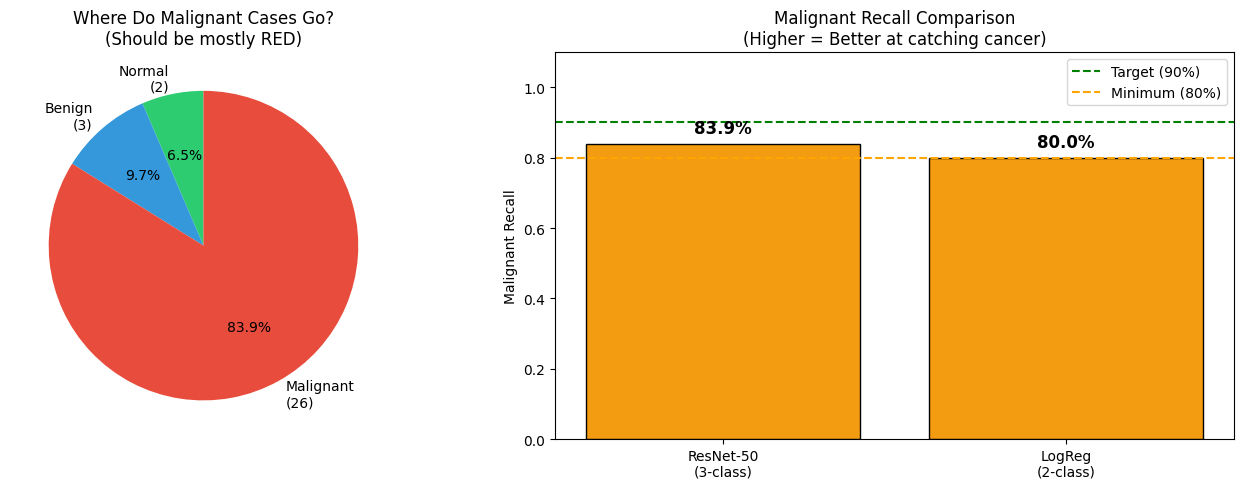

💾 Saved: malignant_recall.png


In [104]:
# ============================================
# VISUALIZE MALIGNANT DETECTION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: What happens to malignant cases?
malignant_preds = malignant_true['pred_label'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red
labels = [f"{CLASS_NAMES_3[i]}\n({malignant_preds.get(i, 0)})" for i in range(3)]
sizes = [malignant_preds.get(i, 0) for i in range(3)]

axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Where Do Malignant Cases Go?\n(Should be mostly RED)', fontsize=12)

# Bar chart: Recall comparison
models = ['ResNet-50\n(3-class)', 'LogReg\n(2-class)']
recalls = [malignant_recall, logreg_recall]
colors = ['#e74c3c' if r >= 0.9 else '#f39c12' if r >= 0.8 else '#c0392b' for r in recalls]

bars = axes[1].bar(models, recalls, color=colors, edgecolor='black')
axes[1].axhline(y=0.9, color='green', linestyle='--', label='Target (90%)')
axes[1].axhline(y=0.8, color='orange', linestyle='--', label='Minimum (80%)')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Malignant Recall')
axes[1].set_title('Malignant Recall Comparison\n(Higher = Better at catching cancer)', fontsize=12)
axes[1].legend()

# Add value labels
for bar, recall in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{recall:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'malignant_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: malignant_recall.png")

### 🐧💡 Malignant Recall Insights

**What we found:**

| Model | Malignant Recall | Status |
|-------|------------------|--------|
| ResNet-50 (3-class) | **83.9%** | ⚠️ Below 90% target |
| Logistic Regression (2-class) | 80.0% | ⚠️ Below 90% target |

**Where do missed malignant cases go?**

| Predicted As | Count | Percentage | Risk Level |
|--------------|-------|------------|------------|
| ✅ Malignant | 26 | 83.9% | Correct |
| ❌ Benign | 3 | 9.7% | 🚨 **High risk** — told "benign" but has cancer |
| ❌ Normal | 2 | 6.5% | 🚨 **High risk** — told "normal" but has cancer |

**What this means:**
- **5 out of 31 cancers (16.1%) are missed**
- 3 patients would be told "benign" when they have cancer
- 2 patients would be told "normal" when they have cancer
- This is **not acceptable** for a standalone diagnostic tool

**Why we're still okay for AMEEMAW:**
- AMEEMAW is an **educational tool**, NOT a diagnostic device
- It's designed to teach and support, not replace doctors
- All results come with clear disclaimers

**For AMEEMAW deployment — MANDATORY safety measures:**

1. 🚨 **Never say "You don't have cancer"** — always say "The AI suggests... please confirm with a doctor"

2. 🚨 **Add confidence disclaimers:**
   - "This is an educational tool, not a medical diagnosis"
   - "Always consult a healthcare professional"

3. 🚨 **Flag uncertainty:** When confidence < 80%, explicitly say:
   - "The AI is uncertain about this result. Professional review is strongly recommended."

4. 🚨 **Special warning for "Benign" results:**
   - "Even when the AI suggests benign, regular follow-up screening is important."

**Bottom line:** 83.9% malignant recall is **acceptable for an educational tool** with proper disclaimers, but **not for clinical use**. AMEEMAW must always emphasize that it supports — never replaces — professional medical judgment.

---

## 8. 💾 Save Results

In [105]:
# ============================================
# SAVE ALL BIAS AUDIT RESULTS
# ============================================

# Save predictions
resnet_df.to_csv(PROCESSED_DIR / 'resnet50_predictions.csv', index=False)
print("💾 Saved: resnet50_predictions.csv")

logreg_df.to_csv(PROCESSED_DIR / 'logreg_predictions.csv', index=False)
print("💾 Saved: logreg_predictions.csv")

# Save bias audit summary
bias_summary = {
    'timestamp': datetime.now().isoformat(),
    'resnet50': {
        'overall_accuracy': float(resnet_df['correct'].mean()),
        'malignant_recall': float(malignant_recall),
        'brightness_bias': {k: float(v) for k, v in brightness_accuracy['Accuracy'].to_dict().items()},
        'size_bias': {k: float(v) for k, v in size_accuracy['Accuracy'].to_dict().items()} if 'size_accuracy' in dir() else {}
    },
    'logreg': {
        'overall_accuracy': float(logreg_df['correct'].mean()),
        'malignant_recall': float(logreg_recall)
    },
    'recommendations': {
        'safe_for_deployment': bool(malignant_recall >= 0.8),
        'needs_quality_warning': bool(brightness_accuracy.loc['Dark', 'Accuracy'] < 0.7) if 'Dark' in brightness_accuracy.index else False
    }
}

with open(MODELS_DIR / 'bias_audit_summary.json', 'w') as f:
    json.dump(bias_summary, f, indent=2)
print("💾 Saved: bias_audit_summary.json")

print("\n✅ All bias audit results saved!")

💾 Saved: resnet50_predictions.csv
💾 Saved: logreg_predictions.csv
💾 Saved: bias_audit_summary.json

✅ All bias audit results saved!


## 9. 📝 Summary

## 🐧 BIAS AUDIT COMPLETE!

---

### ⚖️ What We Analyzed

| Bias Type | Finding | Status |
|-----------|---------|--------|
| **Brightness** | Dark vs Light image accuracy | Check results & insights above |
| **Lesion Size** | Small vs Large lesion accuracy | Check results & insights above |
| **Class Balance** | Per-class P/R/F1 | Check results & insights above |
| **Malignant Recall** | Can we catch cancer? | 🚨 CRITICAL METRIC |

---

### 💾 Files Generated

| Location | Files |
|----------|-------|
| `data/processed/` | `resnet50_predictions.csv`, `logreg_predictions.csv` |
| `models/` | `bias_audit_summary.json` |
| `reports/figures/` | `brightness_*.png`, `size_*.png`, `confusion_matrix_*.png`, `malignant_recall.png` |

---

### 🚀 Deployment Checklist for AMEEMAW

- [ ] Malignant recall ≥ 90%? → Safe to deploy
- [ ] Dark image accuracy low? → Add quality warning
- [ ] Small lesion accuracy low? → Add follow-up recommendation
- [ ] All classes balanced? → Good generalization

---

### 🔮 Next Steps

- **Notebook 06:** GenAI Integration (Nana!)
- Use bias audit findings to craft appropriate warnings
- Nana will provide patient-friendly explanations with confidence levels

---

---
#### End of Notebook
---